# Human M1 Cell Type Classification — Graph Neural Network

**Dataset:** Allen Brain Atlas — Human Primary Motor Cortex (M1) 10x Chromium  
**Task:** Node classification on a cell-cell similarity graph

## Approach vs. CNN / Transformer

| | 1D CNN | Transformer | **GNN** |
|---|---|---|---|
| Input | Gene sequence (1 channel) | Pathway token sequence | Node features on k-NN graph |
| Inductive bias | Local motifs | Global pathway attention | **Cell-cell neighbourhoods** |
| Interpretability | Conv filters | Pathway attention scores | Node embeddings / graph topology |
| Transfer | Gene re-mapping + scaler | Gene re-mapping + unknown detect | **Inductive** — new nodes aggregated from training k-NN |

Each cell is a **node**. Edges connect similar cells (k=15 cosine-NN).  
A 3-layer GraphSAGE encoder with residual connections classifies each node from its neighbourhood context.

## 0. Install Dependencies

In [1]:
%pip install --quiet torch_geometric scanpy polars umap-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 95.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 127.0 MB/s eta 0:00:00


## 1. Imports

In [2]:
import os, gc, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, f1_score, balanced_accuracy_score)
import umap

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv
import polars as pl

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device(
    'cuda' if torch.cuda.is_available() else
    'mps'  if torch.backends.mps.is_available() else 'cpu'
)
print(f'Device: {DEVICE}')
print(f'PyTorch: {torch.__version__}')

Device: cuda
PyTorch: 2.10.0+cu128


## 2. Mount Drive & Load Data

In [3]:
from google.colab import drive
drive.mount('/content/drive')

COLAB_DATA_DIR = '/content/drive/MyDrive/FinalProject/data'
PATHS = {
    'matrix':   os.path.join(COLAB_DATA_DIR, 'aibs_human_m1_10x_matrix.csv'),
    'metadata': os.path.join(COLAB_DATA_DIR, 'aibs_human_m1_10x_metadata.csv'),
}

label_col = 'subclass_label'
id_col    = 'sample_name'

print('Loading metadata...')
meta = pd.read_csv(PATHS['metadata'])

print('Loading expression matrix...')
expr_raw = pl.read_csv(PATHS['matrix'], infer_schema_length=1000).to_pandas()
if 'sample_name' in expr_raw.columns:
    expr_raw.set_index('sample_name', inplace=True)
expr_raw.fillna(0, inplace=True)

meta_indexed  = meta.set_index(id_col)
common_ids    = expr_raw.index.intersection(meta_indexed.index)
expr          = expr_raw.loc[common_ids]
labels_series = meta_indexed.loc[common_ids, label_col]
valid_mask    = labels_series.notna()
expr          = expr[valid_mask]
labels_series = labels_series[valid_mask]
all_gene_names = expr.columns.tolist()

print(f'Dataset: {expr.shape[0]:,} cells x {expr.shape[1]:,} genes')
print(f'Cell types: {labels_series.nunique()}')
del expr_raw, meta_indexed; gc.collect()

Mounted at /content/drive
Loading metadata...
Loading expression matrix...
Dataset: 76,533 cells x 50,281 genes
Cell types: 20


131

## 3. Train / Validation / Test Split

Split **before** any preprocessing to prevent data leakage.

In [4]:
MIN_CELLS_PER_CLASS = 100
class_counts  = labels_series.value_counts()
valid_classes = class_counts[class_counts >= MIN_CELLS_PER_CLASS].index

filtered_mask   = labels_series.isin(valid_classes)
expr_filtered   = expr[filtered_mask]
labels_filtered = labels_series[filtered_mask]

le          = LabelEncoder()
y_all       = le.fit_transform(labels_filtered.values)
class_names = le.classes_
n_classes   = len(class_names)
color_map   = {cls: sns.color_palette('tab20', n_classes)[i] for i, cls in enumerate(class_names)}
print(f'Retained {n_classes} classes across {expr_filtered.shape[0]:,} cells')

X_train_raw, X_temp_raw, y_train, y_temp = train_test_split(
    expr_filtered.values, y_all,
    test_size=0.20, stratify=y_all, random_state=SEED)
X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_temp_raw, y_temp,
    test_size=0.50, stratify=y_temp, random_state=SEED)

print(f'Train: {len(y_train):,}  Val: {len(y_val):,}  Test: {len(y_test):,}')
del expr, expr_filtered; gc.collect()

Retained 17 classes across 76,362 cells
Train: 61,089  Val: 7,636  Test: 7,637


0

## 4. Preprocessing

Same pipeline as the CNN baseline:
1. **Gene filter** — retain genes expressed in ≥ 3.6 % of val cells
2. **HVG selection** — top 200 by variance on val set
3. **Library-size normalize + log1p**
4. **StandardScaler** — fit on train, apply to all splits

In [5]:
N_HVG         = 200
MIN_GENE_FRAC = 0.036

# Discover gene filter + HVGs on val set (no data leakage)
min_cells    = max(3, int(MIN_GENE_FRAC * X_val_raw.shape[0]))
val_gene_mask = (X_val_raw > 0).sum(axis=0) >= min_cells
gene_indices  = np.where(val_gene_mask)[0]
print(f'Genes after filter: {len(gene_indices):,} / {X_val_raw.shape[1]:,}')

def normalize_log(X, gene_idx):
    X = X[:, gene_idx].astype(np.float32)
    lib = X.sum(axis=1, keepdims=True)
    lib = np.where(lib == 0, 1, lib)
    return np.log1p((X / lib) * 1e4)

X_val_norm   = normalize_log(X_val_raw, gene_indices)
top_hvg_idx  = np.argsort(X_val_norm.var(axis=0))[::-1][:N_HVG]
gene_names_hvg = [all_gene_names[gene_indices[i]] for i in top_hvg_idx]

X_train_hvg = normalize_log(X_train_raw, gene_indices)[:, top_hvg_idx]
X_val_hvg   = X_val_norm[:, top_hvg_idx]
X_test_hvg  = normalize_log(X_test_raw,  gene_indices)[:, top_hvg_idx]

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train_hvg).astype(np.float32)
X_val_s   = scaler.transform(X_val_hvg).astype(np.float32)
X_test_s  = scaler.transform(X_test_hvg).astype(np.float32)

print(f'Train: {X_train_s.shape}  Val: {X_val_s.shape}  Test: {X_test_s.shape}')
del X_train_raw, X_val_raw, X_test_raw, X_train_hvg, X_val_hvg, X_test_hvg; gc.collect()

Genes after filter: 16,144 / 50,281
Train: (61089, 200)  Val: (7636, 200)  Test: (7637, 200)


0

## 5. Build Cell-Cell k-NN Graph

Each cell is a **node**; edges connect each cell to its k=15 nearest neighbours in HVG expression space (cosine similarity — standard in scRNA-seq analysis, used by Scanpy/UMAP).

The full graph includes all train + val + test nodes. **Boolean masks** restrict the training loss to training nodes, so test features never directly influence learned weights.

In [6]:
K_NEIGHBORS = 15

X_all           = np.vstack([X_train_s, X_val_s, X_test_s])
y_all_stacked   = np.concatenate([y_train, y_val, y_test])
n_train         = len(y_train)
n_val           = len(y_val)
n_test          = len(y_test)
n_total         = n_train + n_val + n_test

train_mask = torch.zeros(n_total, dtype=torch.bool)
val_mask   = torch.zeros(n_total, dtype=torch.bool)
test_mask  = torch.zeros(n_total, dtype=torch.bool)
train_mask[:n_train]              = True
val_mask  [n_train:n_train+n_val] = True
test_mask [n_train+n_val:]        = True

print(f'Building k={K_NEIGHBORS} cosine-NN graph on {n_total:,} cells...')
nn_finder = NearestNeighbors(n_neighbors=K_NEIGHBORS + 1, metric='cosine', n_jobs=-1)
nn_finder.fit(X_all)
_, indices = nn_finder.kneighbors(X_all)

# Symmetric edge list
src, dst = [], []
for i, nbrs in enumerate(indices):
    for j in nbrs[1:]:          # skip self (index 0)
        src.append(i); dst.append(j)
        src.append(j); dst.append(i)

edge_index = torch.tensor([src, dst], dtype=torch.long)
edge_index = torch.unique(edge_index, dim=1)   # remove duplicates

print(f'Graph: {n_total:,} nodes, {edge_index.shape[1]:,} edges')
print(f'Avg degree: {edge_index.shape[1] / n_total:.1f}')

data = Data(
    x          = torch.from_numpy(X_all),
    edge_index = edge_index,
    y          = torch.from_numpy(y_all_stacked).long(),
    train_mask = train_mask,
    val_mask   = val_mask,
    test_mask  = test_mask,
)
data = data.to(DEVICE)
print(f'\nData: {data}')
del X_train_s, X_val_s, X_test_s; gc.collect()

Building k=15 cosine-NN graph on 76,362 cells...
Graph: 76,362 nodes, 1,858,284 edges
Avg degree: 24.3

Data: Data(x=[76362, 200], edge_index=[2, 1858284], y=[76362], train_mask=[76362], val_mask=[76362], test_mask=[76362])


456

## 6. GraphSAGE Architecture

**GraphSAGE** (Hamilton et al., 2017) aggregates neighbour features inductively:

> $h_v^{(l)} = σ( W · CONCAT( h_v^{(l-1)}, MEAN_{u∈N(v)} h_u^{(l-1)} ) )$

Key properties:
- **Inductive** — generalises to unseen nodes without retraining (needed for SMART-seq transfer)
- **MEAN aggregator** — robust to noisy scRNA-seq counts
- **Residual connections** — prevent over-smoothing in deeper networks

```
Input (200)
  → ResidualSAGEBlock(200 → 256)  [SAGEConv + LayerNorm + GELU + residual]
  → ResidualSAGEBlock(256 → 256)  [same]
  → SAGEConv(256 → 128) + GELU
  → LayerNorm → Linear(128 → n_classes)
```

In [7]:
class ResidualSAGEBlock(nn.Module):
    """SAGEConv with LayerNorm, GELU, and a residual projection."""
    def __init__(self, in_dim, out_dim, dropout=0.3):
        super().__init__()
        self.conv    = SAGEConv(in_dim, out_dim)
        self.norm    = nn.LayerNorm(out_dim)
        self.dropout = dropout
        self.proj    = nn.Linear(in_dim, out_dim, bias=False) if in_dim != out_dim else nn.Identity()

    def forward(self, x, edge_index):
        h = self.conv(x, edge_index)
        h = self.norm(h)
        h = F.gelu(h)
        h = F.dropout(h, p=self.dropout, training=self.training)
        return h + self.proj(x)


class CellTypeGNN(nn.Module):
    def __init__(self, in_dim, hidden_dim, n_classes, dropout=0.3):
        super().__init__()
        self.block1    = ResidualSAGEBlock(in_dim,     hidden_dim, dropout)
        self.block2    = ResidualSAGEBlock(hidden_dim, hidden_dim, dropout)
        self.conv_out  = SAGEConv(hidden_dim, hidden_dim // 2)
        self.classifier = nn.Sequential(
            nn.LayerNorm(hidden_dim // 2),
            nn.Linear(hidden_dim // 2, n_classes),
        )

    def forward(self, x, edge_index):
        x = self.block1(x, edge_index)
        x = self.block2(x, edge_index)
        x = F.gelu(self.conv_out(x, edge_index))
        return self.classifier(x)

    def embed(self, x, edge_index):
        """Pre-classifier embedding (for UMAP / transfer)."""
        x = self.block1(x, edge_index)
        x = self.block2(x, edge_index)
        return F.gelu(self.conv_out(x, edge_index))


HIDDEN_DIM = 256
model_gnn  = CellTypeGNN(N_HVG, HIDDEN_DIM, n_classes).to(DEVICE)
total_params = sum(p.numel() for p in model_gnn.parameters())
print(f'GNN parameters: {total_params:,}')
print(model_gnn)

GNN parameters: 354,321
CellTypeGNN(
  (block1): ResidualSAGEBlock(
    (conv): SAGEConv(200, 256, aggr=mean)
    (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (proj): Linear(in_features=200, out_features=256, bias=False)
  )
  (block2): ResidualSAGEBlock(
    (conv): SAGEConv(256, 256, aggr=mean)
    (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (proj): Identity()
  )
  (conv_out): SAGEConv(256, 128, aggr=mean)
  (classifier): Sequential(
    (0): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (1): Linear(in_features=128, out_features=17, bias=True)
  )
)


## 7. Training

In [8]:
class_counts_train = np.bincount(y_train, minlength=n_classes).astype(np.float32)
class_weights = torch.tensor(1.0 / (class_counts_train + 1e-6)).to(DEVICE)
class_weights = class_weights / class_weights.sum() * n_classes

criterion    = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
EPOCHS       = 200
LR           = 3e-4
WEIGHT_DECAY = 1e-5
optimizer    = optim.AdamW(model_gnn.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler    = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

best_val_acc = 0.0
best_ckpt    = 'best_gnn_model.pt'
patience     = 20
no_improve   = 0
history      = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(1, EPOCHS + 1):
    # Train
    model_gnn.train()
    optimizer.zero_grad()
    logits = model_gnn(data.x, data.edge_index)
    loss   = criterion(logits[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    scheduler.step()
    train_acc = (logits[data.train_mask].argmax(1) == data.y[data.train_mask]).float().mean().item()

    # Validate
    model_gnn.eval()
    with torch.no_grad():
        logits_v = model_gnn(data.x, data.edge_index)
        val_loss = criterion(logits_v[data.val_mask], data.y[data.val_mask]).item()
        val_acc  = (logits_v[data.val_mask].argmax(1) == data.y[data.val_mask]).float().mean().item()

    history['train_loss'].append(loss.item())
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model_gnn.state_dict(), best_ckpt)
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f'Early stopping at epoch {epoch}')
            break

    if epoch % 20 == 0 or epoch == 1:
        print(f'Epoch {epoch:>3} | loss {loss.item():.4f} | val_loss {val_loss:.4f} | val_acc {val_acc:.4f}')

print(f'\nBest val accuracy: {best_val_acc:.4f}')

Epoch   1 | loss 4.3226 | val_loss 3.7697 | val_acc 0.1527
Epoch  20 | loss 2.1715 | val_loss 2.1336 | val_acc 0.5910
Early stopping at epoch 33

Best val accuracy: 0.6366


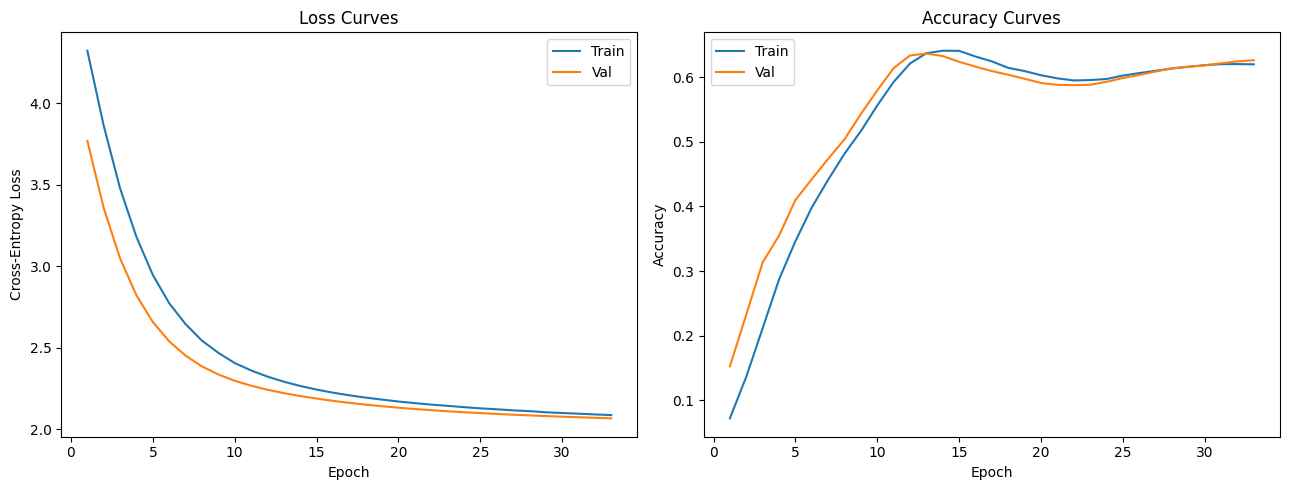

Saved fig_gnn_training_curves.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ep = range(1, len(history['train_loss']) + 1)
axes[0].plot(ep, history['train_loss'], label='Train')
axes[0].plot(ep, history['val_loss'],   label='Val')
axes[0].set(xlabel='Epoch', ylabel='Cross-Entropy Loss', title='Loss Curves')
axes[0].legend()
axes[1].plot(ep, history['train_acc'], label='Train')
axes[1].plot(ep, history['val_acc'],   label='Val')
axes[1].set(xlabel='Epoch', ylabel='Accuracy', title='Accuracy Curves')
axes[1].legend()
plt.tight_layout()
plt.savefig('fig_gnn_training_curves.png', dpi=150)
plt.show()
print('Saved fig_gnn_training_curves.png')

## 8. Test Set Evaluation

Test Accuracy:     0.6317 (63.17%)
Balanced Accuracy: 0.9005
Macro F1:          0.8514

              precision    recall  f1-score   support

       Astro      0.934     1.000     0.966        57
     L2/3 IT      1.000     0.141     0.247      2423
       L5 ET      1.000     0.988     0.994        86
       L5 IT      0.971     0.612     0.751      1384
     L5/6 NP      1.000     1.000     1.000       148
       L6 CT      1.000     1.000     1.000       374
       L6 IT      0.915     0.995     0.953       183
  L6 IT Car3      0.889     1.000     0.941        32
         L6b      1.000     1.000     1.000       224
       Lamp5      0.998     0.935     0.965       446
   Micro-PVM      0.004     0.909     0.007        11
         OPC      0.966     1.000     0.982        28
       Oligo      1.000     0.963     0.981       294
       Pvalb      0.986     0.886     0.933       778
        Sncg      0.693     0.989     0.815        89
         Sst      0.986     0.918     0.950    

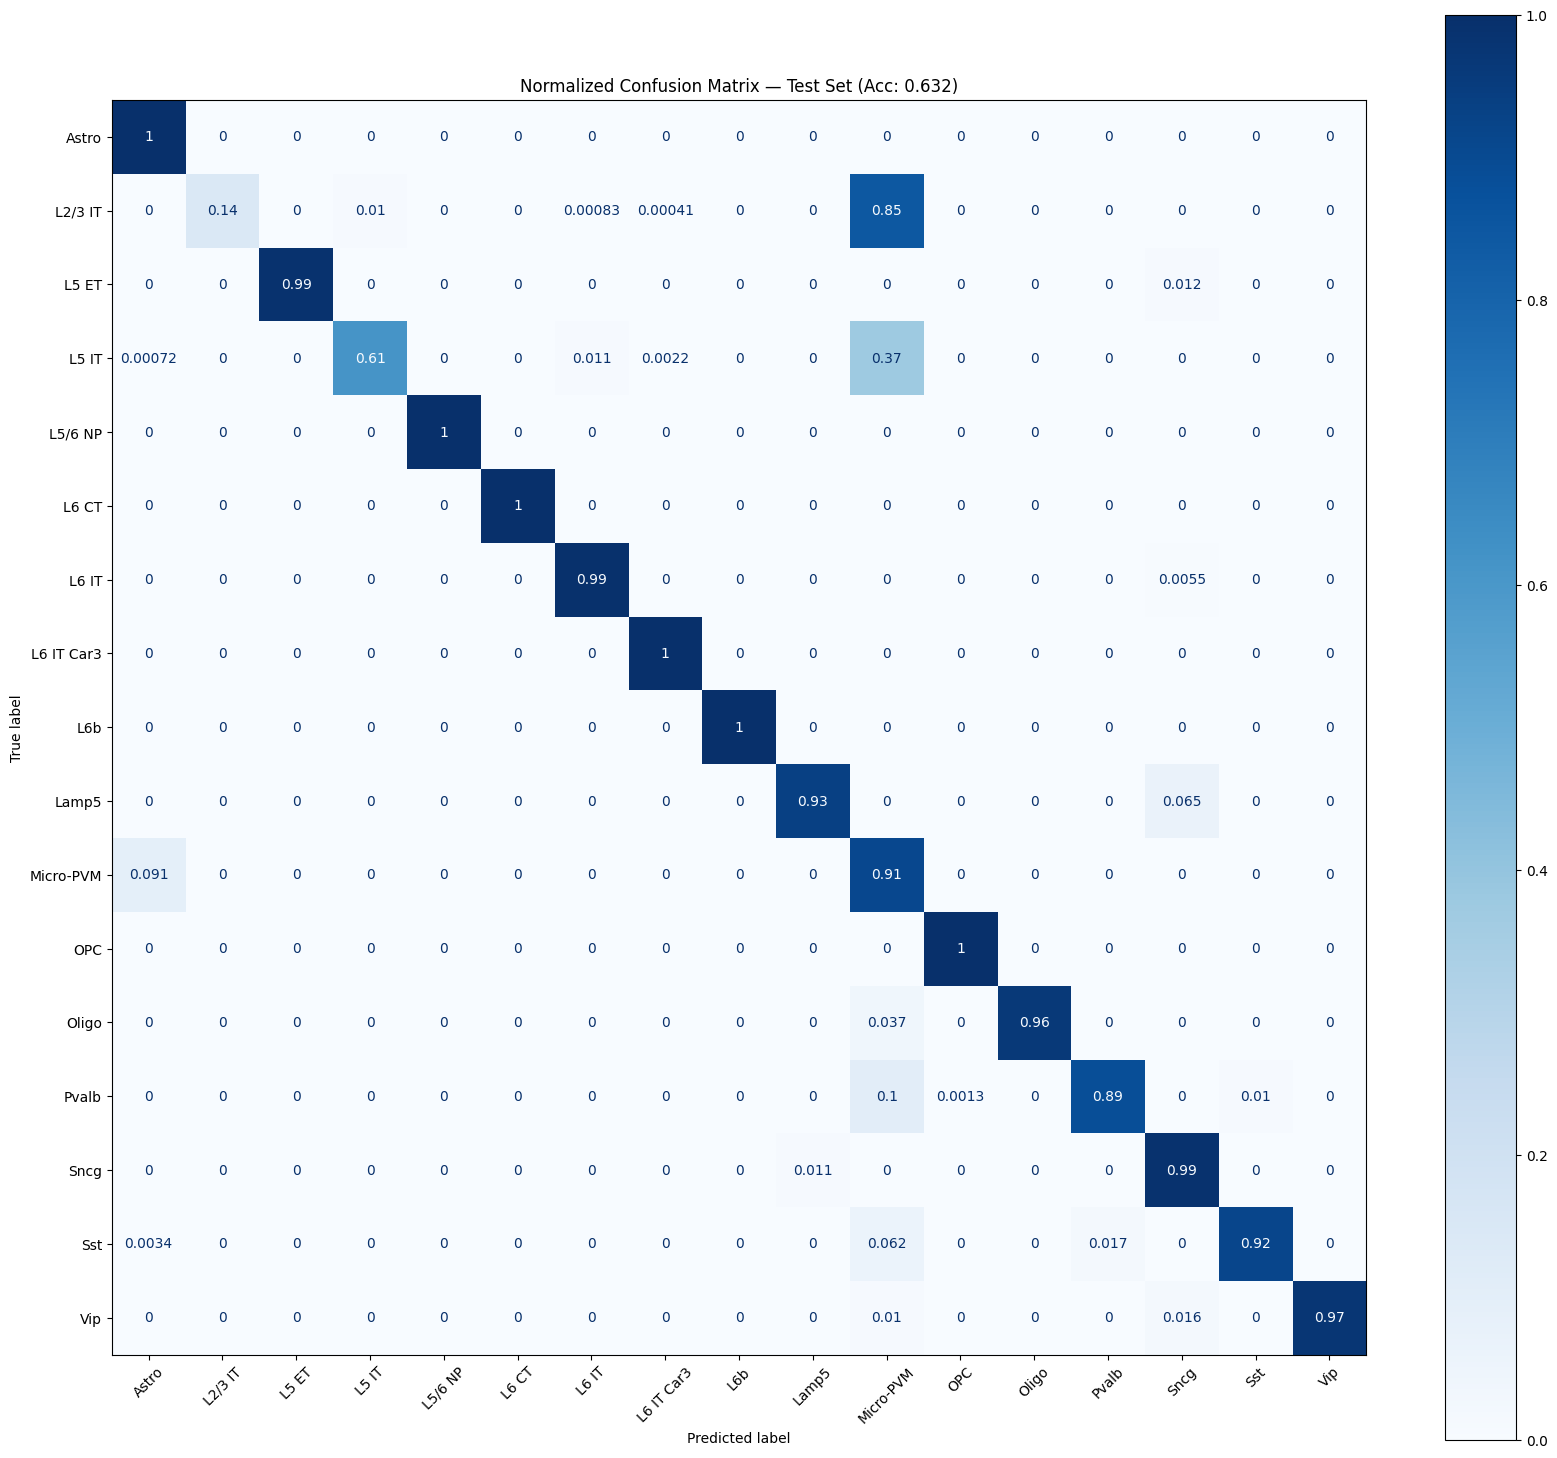

In [10]:
model_gnn.load_state_dict(torch.load(best_ckpt, map_location=DEVICE))
model_gnn.eval()

with torch.no_grad():
    logits_test = model_gnn(data.x, data.edge_index)
    all_preds   = logits_test[data.test_mask].argmax(1).cpu().numpy()
    all_true    = data.y[data.test_mask].cpu().numpy()

test_acc = (all_preds == all_true).mean()
print(f'Test Accuracy:     {test_acc:.4f} ({test_acc*100:.2f}%)')
print(f'Balanced Accuracy: {balanced_accuracy_score(all_true, all_preds):.4f}')
print(f'Macro F1:          {f1_score(all_true, all_preds, average="macro"):.4f}')
print()
print(classification_report(all_true, all_preds, target_names=class_names, digits=3))

cm = confusion_matrix(all_true, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(max(10, n_classes), max(8, n_classes - 2)))
ConfusionMatrixDisplay(cm_norm, display_labels=class_names).plot(
    ax=ax, cmap='Blues', colorbar=True, xticks_rotation=45)
ax.set_title(f'Normalized Confusion Matrix — Test Set (Acc: {test_acc:.3f})')
plt.tight_layout()
plt.savefig('fig_gnn_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. UMAP of GNN Node Embeddings

Unlike the CNN (features = raw HVG expression) the GNN embedding encodes **neighbourhood context** — similar cell types that co-cluster in the graph also cluster in embedding space.

Running UMAP on 3000 GNN embeddings...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


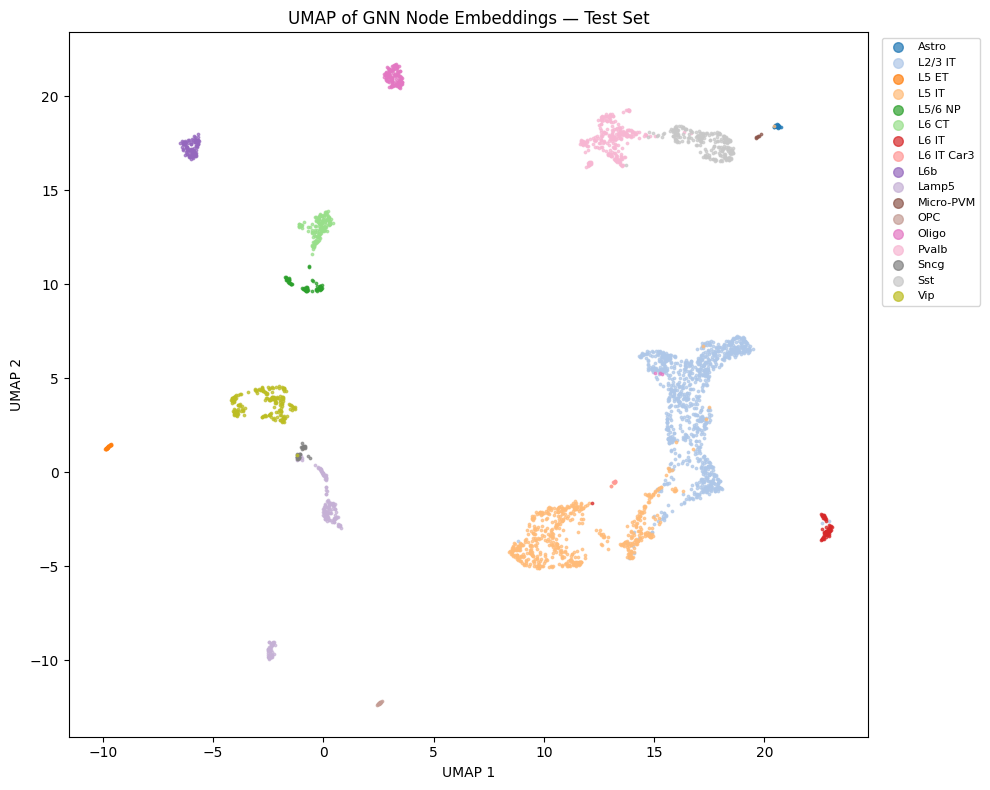

Saved fig_gnn_umap.png


In [11]:
model_gnn.eval()
with torch.no_grad():
    embeddings = model_gnn.embed(data.x, data.edge_index).cpu().numpy()

test_emb   = embeddings[data.test_mask.cpu().numpy()]
test_names = le.inverse_transform(all_true)

MAX_CELLS = 3000
if len(test_emb) > MAX_CELLS:
    idx        = np.random.choice(len(test_emb), MAX_CELLS, replace=False)
    test_emb   = test_emb[idx]
    test_names = test_names[idx]

print(f'Running UMAP on {test_emb.shape[0]} GNN embeddings...')
reducer  = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.3, random_state=SEED)
umap_emb = reducer.fit_transform(test_emb)

fig, ax = plt.subplots(figsize=(10, 8))
for cls in class_names:
    m = test_names == cls
    if m.sum() == 0: continue
    ax.scatter(umap_emb[m, 0], umap_emb[m, 1], c=[color_map[cls]], s=3, alpha=0.7, label=cls)
ax.set(xlabel='UMAP 1', ylabel='UMAP 2',
       title='UMAP of GNN Node Embeddings — Test Set')
ax.legend(markerscale=4, fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('fig_gnn_umap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig_gnn_umap.png')

## 10. Cross-Dataset Transfer — SMART-seq

**Inductive transfer with GraphSAGE:**

New SMART-seq cells are connected only to their k-NN in the **training set**.  
The trained GraphSAGE encoder aggregates from those training neighbours to embed each new cell, then classifies it — no retraining required.

In [12]:
NEW_MATRIX_PATH = '/content/drive/MyDrive/FinalProject/HumanMultipleCorticalAreasSMARTseq_matrix.csv'
NEW_META_PATH   = '/content/drive/MyDrive/FinalProject/HumanMultipleCorticalAreasSMARTseq_meta.csv'

# ── Load with same gene mapping (polars, same as CNN/Transformer) ─────────────
print('Reading CSV header...')
all_cols     = pl.read_csv(NEW_MATRIX_PATH, n_rows=0).columns
col_set      = set(all_cols)
has_sid      = 'sample_name' in col_set
found_genes  = [g for g in gene_names_hvg if g in col_set]
missing      = [g for g in gene_names_hvg if g not in col_set]
cols_to_load = (['sample_name'] if has_sid else []) + found_genes

print(f'HVG genes found: {len(found_genes)}/{len(gene_names_hvg)}')
if missing:
    print(f'Missing ({len(missing)}): {missing[:10]}{"..." if len(missing) > 10 else ""}')

df = pl.read_csv(NEW_MATRIX_PATH, columns=cols_to_load, null_values=['', 'NA', 'NaN'])
print(f'Loaded: {df.shape[0]:,} cells x {df.shape[1]:,} columns')

meta_new = pl.read_csv(NEW_META_PATH,
                       columns=['sample_name', 'subclass_label'],
                       null_values=['', 'NA', 'NaN']
                       ).filter(pl.col('subclass_label').is_not_null())
if has_sid:
    df = df.join(meta_new, on='sample_name', how='inner')
del meta_new; gc.collect()

new_labels = df['subclass_label'].to_pandas()
drop_cols  = [c for c in ('sample_name', 'subclass_label') if c in df.columns]
df         = df.drop(drop_cols)
print(f'Aligned: {df.shape[0]:,} cells, {new_labels.nunique()} cell types')

# Build gene-aligned array (zeros for missing genes)
gene_index = {g: i for i, g in enumerate(gene_names_hvg)}
new_hvg    = np.zeros((df.shape[0], N_HVG), dtype=np.float32)
for gene in found_genes:
    new_hvg[:, gene_index[gene]] = df[gene].cast(pl.Float32).fill_null(0.0).to_numpy()
del df; gc.collect()

# Preprocess: lib-size normalize + log1p + scaler (same as training)
lib     = new_hvg.sum(axis=1, keepdims=True)
lib     = np.where(lib == 0, 1, lib)
new_hvg = np.log1p((new_hvg / lib) * 1e4)
X_new   = scaler.transform(new_hvg).astype(np.float32)
del new_hvg; gc.collect()
print(f'Preprocessed: {X_new.shape}')

Reading CSV header...
HVG genes found: 200/200
Loaded: 49,417 cells x 201 columns
Aligned: 47,432 cells, 19 cell types
Preprocessed: (47432, 200)


In [13]:
# ── Build inductive graph: SMART-seq → training k-NN ────────────────────────
X_train_cpu = data.x[data.train_mask].cpu().numpy()
n_new       = len(X_new)
n_tr        = len(X_train_cpu)

print(f'Connecting {n_new:,} SMART-seq cells to k={K_NEIGHBORS} training neighbours...')
nn_train = NearestNeighbors(n_neighbors=K_NEIGHBORS, metric='cosine', n_jobs=-1)
nn_train.fit(X_train_cpu)
_, nbr_idx = nn_train.kneighbors(X_new)   # (n_new, K)

# Training nodes: [0, n_tr)   SMART-seq nodes: [n_tr, n_tr+n_new)
src_e, dst_e = [], []
for q_i, neighbors in enumerate(nbr_idx):
    nid = n_tr + q_i
    for tr_id in neighbors:
        src_e.append(tr_id); dst_e.append(nid)   # train → new
        src_e.append(nid);   dst_e.append(tr_id)  # new → train (symmetric)

new_edge_index = torch.tensor([src_e, dst_e], dtype=torch.long)
X_combined     = np.vstack([X_train_cpu, X_new])
new_node_mask  = torch.zeros(n_tr + n_new, dtype=torch.bool)
new_node_mask[n_tr:] = True

data_infer = Data(
    x          = torch.from_numpy(X_combined).to(DEVICE),
    edge_index = new_edge_index.to(DEVICE),
)

# ── Inference ─────────────────────────────────────────────────────────────────
model_gnn.eval()
with torch.no_grad():
    logits_new = model_gnn(data_infer.x, data_infer.edge_index)
    probs_new  = F.softmax(logits_new[new_node_mask.to(DEVICE)], dim=-1)
    _, preds_new = probs_new.max(dim=-1)

new_preds   = preds_new.cpu().numpy()
pred_labels = le.inverse_transform(new_preds)
print(f'\nPrediction distribution:')
print(pd.Series(pred_labels).value_counts())

Connecting 47,432 SMART-seq cells to k=15 training neighbours...

Prediction distribution:
L5 IT         7748
L2/3 IT       7207
Micro-PVM     7084
L6 IT         4212
Pvalb         2908
Vip           2480
Lamp5         2221
L6 CT         2200
Sst           2176
Oligo         1931
Sncg          1612
L6b           1439
L6 IT Car3    1228
Astro         1218
OPC            819
L5/6 NP        814
L5 ET          135
Name: count, dtype: int64


Cells with known labels: 16,508 / 47,432
Case-mapped: {'VIP': 'Vip', 'LAMP5': 'Lamp5', 'SST': 'Sst', 'PVALB': 'Pvalb'}
Unmatched (10): ['Astrocyte', 'Endothelial', 'IT', 'L4 IT', 'L5/6 IT Car3', 'Microglia', 'Oligodendrocyte', 'PAX6', 'Pericyte', 'VLMC']

Transfer Accuracy: 0.8856 (88.56%)

              precision    recall  f1-score   support

     L2/3 IT      0.000     0.000     0.000         0
       L5 ET      1.000     0.848     0.918       158
     L5/6 NP      1.000     0.998     0.999       816
       L6 CT      0.997     0.858     0.922      2556
  L6 IT Car3      0.000     0.000     0.000         0
         L6b      0.748     0.995     0.854      1080
       Lamp5      0.998     0.909     0.951      2434
   Micro-PVM      0.000     0.000     0.000         0
         OPC      0.994     1.000     0.997       773
       Oligo      0.000     0.000     0.000         0
       Pvalb      0.953     0.989     0.971      2800
        Sncg      0.000     0.000     0.000         0
     

/tmp/ipykernel_10220/1956100306.py:30: RuntimeWarning: invalid value encountered in divide
  cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)


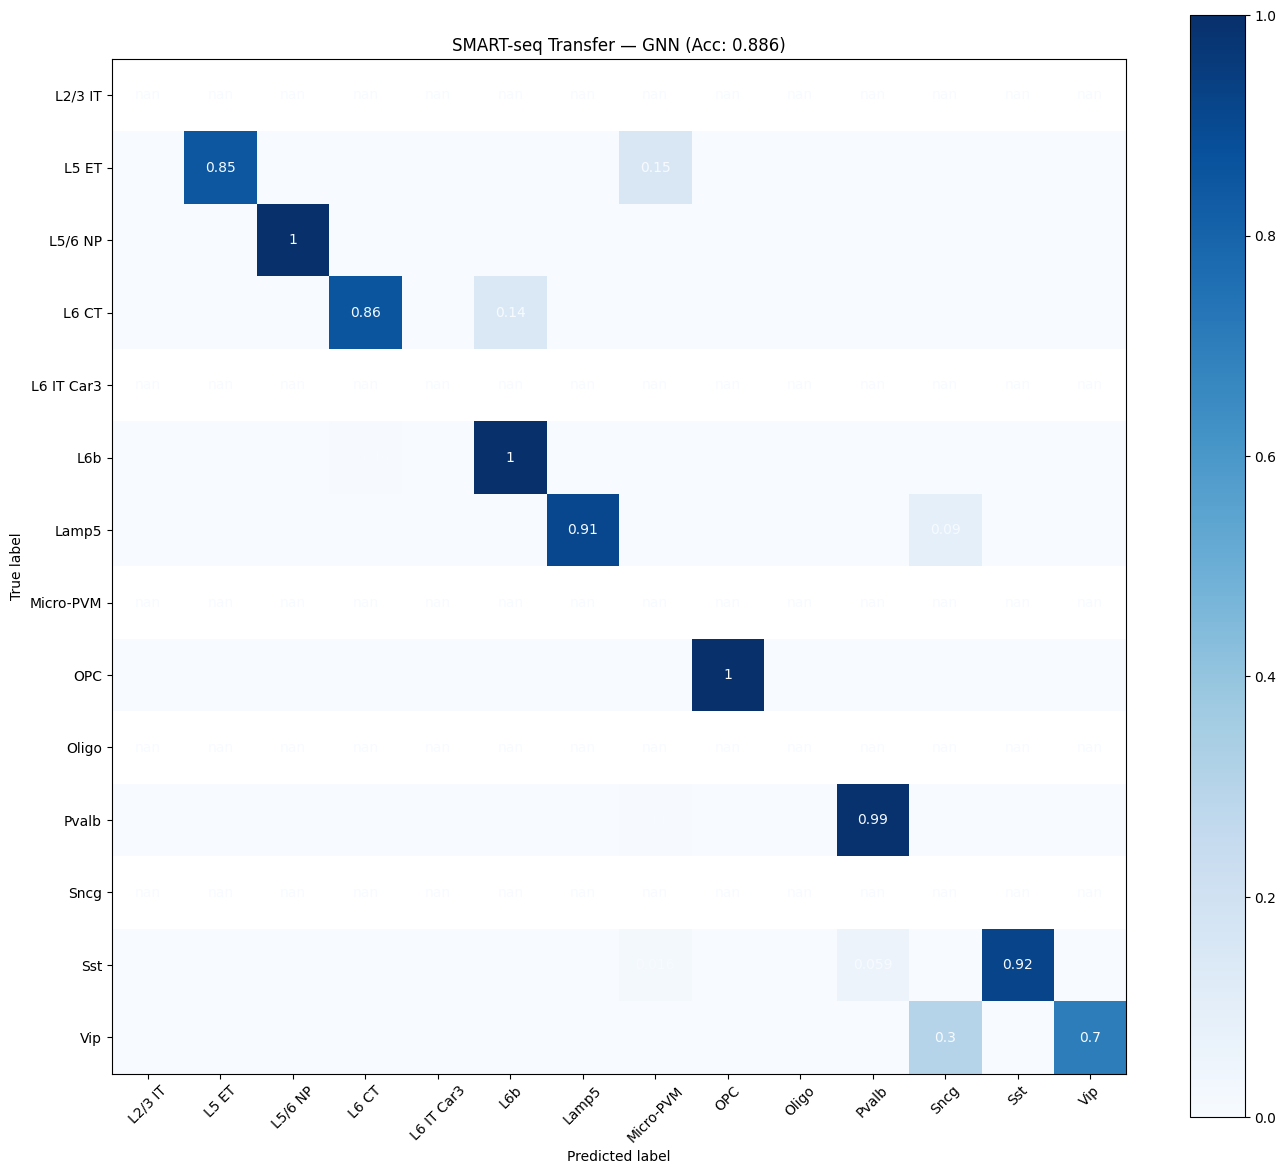

In [14]:
# ── Case-insensitive evaluation ───────────────────────────────────────────────
train_lower   = {c.lower(): c for c in class_names}
label_map     = {lbl: train_lower.get(lbl.lower(), lbl) for lbl in new_labels.unique()}
mapped_labels = new_labels.map(label_map)

known_mask = mapped_labels.isin(class_names)
print(f'Cells with known labels: {known_mask.sum():,} / {len(new_labels):,}')

mapped_pairs = {k: v for k, v in label_map.items() if k != v and v in class_names}
if mapped_pairs:
    print(f'Case-mapped: {mapped_pairs}')
unknown_classes = sorted(set(mapped_labels.unique()) - set(class_names))
if unknown_classes:
    print(f'Unmatched ({len(unknown_classes)}): {unknown_classes}')

if known_mask.sum() > 0:
    true_enc = le.transform(mapped_labels[known_mask].values)
    pred_enc = new_preds[known_mask.values]
    acc = (true_enc == pred_enc).mean()
    print(f'\nTransfer Accuracy: {acc:.4f} ({acc*100:.2f}%)')
    print()

    present_enc   = np.unique(np.concatenate([true_enc, pred_enc]))
    present_names = le.inverse_transform(present_enc)
    print(classification_report(true_enc, pred_enc,
                                 labels=present_enc, target_names=present_names,
                                 digits=3, zero_division=0))

    cm      = confusion_matrix(true_enc, pred_enc, labels=present_enc)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    dim     = max(10, len(present_enc))
    fig, ax = plt.subplots(figsize=(dim, max(8, dim - 2)))
    ConfusionMatrixDisplay(cm_norm, display_labels=present_names).plot(
        ax=ax, cmap='Blues', colorbar=True, xticks_rotation=45)
    ax.set_title(f'SMART-seq Transfer — GNN (Acc: {acc:.3f})')
    plt.tight_layout()
    plt.savefig('fig_gnn_smartseq_confusion.png', dpi=150, bbox_inches='tight')
    plt.show()

## 11. Summary

| Component | Detail |
|---|---|
| Graph | k-NN, k=15, cosine similarity, symmetric |
| Node features | 200 HVGs — lib-size norm + log1p + z-score |
| Architecture | 3-layer GraphSAGE + residual connections |
| Training | Full-batch, class-weighted CE, cosine LR, early stopping |
| Transfer | Inductive — SMART-seq nodes aggregated from training k-NN |

### Key design choices
- **Symmetric k-NN** — each cell aggregates from its own neighbourhood in both directions
- **Residual SAGEConv blocks** — stabilise deeper networks and prevent over-smoothing
- **StandardScaler** — same as CNN, ensures consistent feature scale before graph construction
- **Inductive transfer** — GraphSAGE can embed new nodes without any retraining